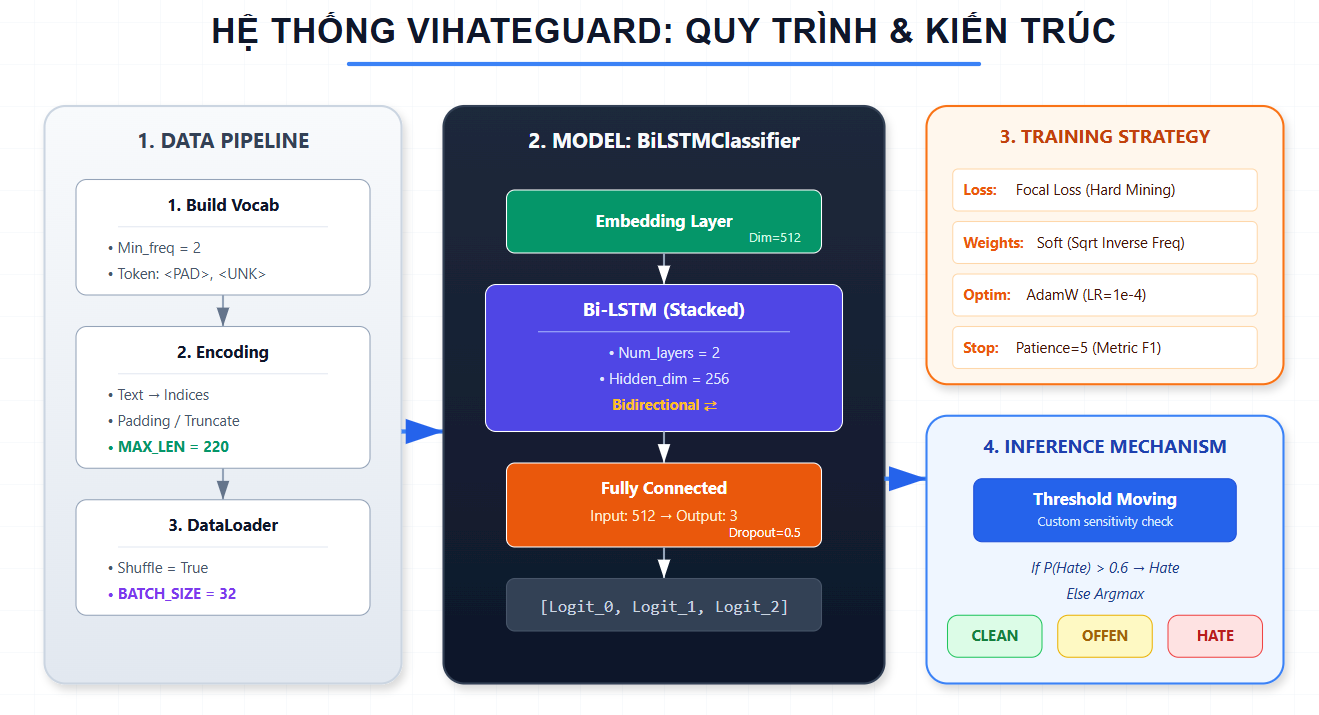

In [2]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import numpy as np
import torch
import json
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import re
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# --- 1. CẤU HÌNH (CONFIG) ---
config = {
    "TRAIN_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\data\processed\train.csv",
    "VALID_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\data\processed\valid.csv",
    "MODEL_SAVE_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\models_best\best_model.pth",
    "MAX_LEN": 220,        # Độ dài tối đa của câu
    "EMBEDDING_DIM": 512,    # Kích thước vector từ (Học từ đầu)
    "HIDDEN_DIM": 256,       # Số nơ-ron LSTM
    "BATCH_SIZE": 32,
    "EPOCHS": 40,            # Train from scratch cần nhiều epochs hơn
    "LR": 0.0001,
    "PATIENCE": 5,           # Dừng sớm nếu không cải thiện sau 5 epochs
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu"
}

In [35]:
# --- 2. XÂY DỰNG TỪ ĐIỂN (VOCABULARY) ---
class Vocabulary:
    def __init__(self):
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word = {0: "<PAD>", 1: "<UNK>"}
        self.idx = 2

    def build_vocab(self, texts, min_freq=2):
        print("-> Đang xây dựng từ điển (Vocabulary)...")
        counter = Counter()
        for text in texts:
            words = str(text).lower().split()
            counter.update(words)
        
        # Chỉ giữ từ xuất hiện >= min_freq lần
        for word, count in counter.items():
            if count >= min_freq:
                self.word2idx[word] = self.idx
                self.idx2word[self.idx] = word
                self.idx += 1
        print(f"   Kích thước từ điển: {len(self.word2idx)} từ")

    def encode(self, text, max_len):
        words = str(text).lower().split()
        # Chuyển từ thành số. Nếu từ lạ -> <UNK> (1)
        indices = [self.word2idx.get(w, 1) for w in words]
        
        # Padding hoặc Cắt
        if len(indices) < max_len:
            indices += [0] * (max_len - len(indices)) # 0 là <PAD>
        else:
            indices = indices[:max_len]
        return indices


In [36]:
# --- 3. DATASET ---
class HateDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Input: list các số nguyên (Indices)
        x = torch.tensor(self.vocab.encode(self.texts[idx], self.max_len), dtype=torch.long)
        # Label
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

In [37]:
# --- 4. MÔ HÌNH BI-LSTM (MODEL ARCHITECTURE) ---
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.4):
        super(BiLSTMClassifier, self).__init__()
        
        # Lớp Embedding: Học ma trận biểu diễn từ (Thay thế PhoBERT)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Lớp Bi-LSTM
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=2,           # 2 lớp chồng lên nhau cho sâu
            bidirectional=True,     # QUAN TRỌNG: Đọc 2 chiều
            batch_first=True,
            dropout=dropout
        )
        
        # Lớp phân loại (Fully Connected)
        # hidden_dim * 2 vì có 2 chiều (Xuôi + Ngược)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: [batch, max_len]
        emb = self.dropout(self.embedding(x)) # [batch, max_len, emb_dim]
        
        # LSTM out: [batch, max_len, hidden*2]
        # hidden: [layers*2, batch, hidden]
        out, (hidden, cell) = self.lstm(emb)
        
        # Lấy Hidden State cuối cùng của chiều xuôi và chiều ngược nối lại
        # hidden[-2]: Lớp cuối chiều Xuôi
        # hidden[-1]: Lớp cuối chiều Ngược
        hidden_final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        logits = self.fc(self.dropout(hidden_final))
        return logits


In [ ]:
# 5. CÁC HÀM HỖ TRỢ (LOSS & PREDICT) 
# 5.1 Focal Loss (Giúp model tập trung vào mẫu khó)
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.weight = weight

    def forward(self, inputs, targets):
        # inputs: logits [batch, num_classes]
        # targets: labels [batch]
        
        CE_loss = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(inputs, targets)
        pt = torch.exp(-CE_loss) # Xác suất dự đoán đúng lớp target
        
        # Công thức Focal Loss: FL = alpha * (1-pt)^gamma * CE
        F_loss = self.alpha * (1-pt)**self.gamma * CE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss

# 5.2 Threshold Moving (Thay đổi ngưỡng quyết định)
def predict_with_threshold(logits, threshold_hate=0.5, threshold_offensive=0.5):
    """
    Thay vì chọn nhãn có xác suất cao nhất (argmax), ta hạ thấp ngưỡng cho các lớp thiểu số.
    """
    probs = torch.softmax(logits, dim=1) # Chuyển logits thành xác suất [0, 1]
    
    # Mặc định lấy nhãn có xác suất cao nhất
    preds = torch.argmax(probs, dim=1)
    
    # Lấy xác suất của từng lớp (0: Clean, 1: Offensive, 2: Hate)
    prob_offensive = probs[:, 1]
    prob_hate = probs[:, 2]
    
    # Áp dụng ngưỡng (Ưu tiên Hate > Offensive)
    # Nếu xác suất Hate > ngưỡng -> Gán là Hate (2)
    mask_hate = prob_hate > threshold_hate
    preds[mask_hate] = 2
    
    # Nếu không phải Hate mà xác suất Offensive > ngưỡng -> Gán là Offensive (1)
    mask_offensive = (prob_offensive > threshold_offensive) & (~mask_hate)
    preds[mask_offensive] = 1
    
    return preds

In [ ]:
# --- 5. HÀM ĐỌC DỮ LIỆU ---
def load_data(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=['free_text', 'label_id'])
    return df['free_text'].astype(str).tolist(), df['label_id'].astype(int).tolist()

In [ ]:
# --- 6. QUY TRÌNH TRAIN ---
def train():
    device = config["DEVICE"]
    print(f"--- THIẾT BỊ: {device} ---")
    
    # 1. Load Data
    print("-> Đang tải dữ liệu...")
    train_texts, train_labels = load_data(config["TRAIN_PATH"])
    val_texts, val_labels = load_data(config["VALID_PATH"])
    
    print(f"   Train size: {len(train_texts)}")
    print(f"   Valid size: {len(val_texts)}")
    
    # 2. Build Vocab
    vocab = Vocabulary()
    vocab.build_vocab(train_texts) 
    vocab_save_path = r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\models_best\bilstm_best_vocab.json"
    os.makedirs(os.path.dirname(vocab_save_path), exist_ok=True)
    with open(vocab_save_path, 'w', encoding='utf-8') as f:
        json.dump(vocab.word2idx, f, ensure_ascii=False)
    # 3. Create Dataset
    train_ds = HateDataset(train_texts, train_labels, vocab, config["MAX_LEN"])
    val_ds = HateDataset(val_texts, val_labels, vocab, config["MAX_LEN"])
    
    # --- SOFT CLASS WEIGHTS: Dùng căn bậc 2 để giảm bớt sự cực đoan ---
    print("-> Đang tính toán Soft Class Weights...")
    class_counts = Counter(train_labels)
    print(f"   Phân bố gốc: {class_counts}")
    
    total_samples = sum(class_counts.values())
    n_classes = 3
    
    weights = []
    for i in range(n_classes):
        count = class_counts.get(i, 0)
        if count > 0:
            # CÔNG THỨC MỚI: Căn bậc 2 của Inverse Frequency
            # Giúp cân bằng hơn: Vẫn ưu tiên Hate nhưng không quá mức
            w = np.sqrt(total_samples / (n_classes * count))
        else:
            w = 1.0
        weights.append(w)
        
    class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
    print(f"   Soft Class Weights: {weights}")
    
    # DataLoader
    train_loader = DataLoader(train_ds, batch_size=config["BATCH_SIZE"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config["BATCH_SIZE"], shuffle=False)
    
    # 4. Init Model
    model = BiLSTMClassifier(
        vocab_size=len(vocab.word2idx),
        embedding_dim=config["EMBEDDING_DIM"],
        hidden_dim=config["HIDDEN_DIM"],
        output_dim=3,
        dropout=0.5
    )
    model.to(device)
    
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=config["LR"], weight_decay=1e-4)
    
    # Loss Function
    print("-> Sử dụng Focal Loss với Soft Weights...")
    criterion = FocalLoss(alpha=1, gamma=2, weight=class_weights_tensor, reduction='mean') 

    # 5. Training Loop
    best_f1 = 0.0
    patience_counter = 0
    patience_limit = config["PATIENCE"]
    
    print("\n--- BẮT ĐẦU TRAINING ---")
    
    for epoch in range(config["EPOCHS"]):
        model.train()
        train_loss = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # Validation
        model.eval()
        all_preds = []
        all_labels = []
        val_loss = 0
        
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item()
                
                # --- TĂNG NGƯỠNG (THRESHOLD) ---
                # Vì model đang quá nhạy (Precision thấp), ta tăng ngưỡng lên 0.6
                # Nghĩa là phải > 60% chắc chắn mới gán là Hate
                preds = predict_with_threshold(logits, threshold_hate=0.6, threshold_offensive=0.6)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        
        # Tính metrics
        report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
        macro_f1 = report['macro avg']['f1-score']
        
        print(f"Epoch {epoch+1}/{config['EPOCHS']} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Macro F1: {macro_f1:.4f}")
        
        if macro_f1 > best_f1:
            best_f1 = macro_f1
            torch.save(model.state_dict(), config["MODEL_SAVE_PATH"])
            print(f"   --> Model tốt nhất mới (F1: {best_f1:.4f})! Đã lưu.")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"   --> Không cải thiện. Patience: {patience_counter}/{patience_limit}")
            if patience_counter >= patience_limit:
                print("   --> DỪNG SỚM (EARLY STOPPING)!")
                break
            
    # IN KẾT QUẢ CUỐI CÙNG
    print("\n BÁO CÁO KẾT QUẢ CUỐI CÙNG (MODEL TỐT NHẤT) ")
    model.eval()
    final_preds = []
    final_labels = []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            
            # Dùng ngưỡng cao cho kết quả cuối cùng
            preds = predict_with_threshold(logits, threshold_hate=0.6, threshold_offensive=0.6)
            
            final_preds.extend(preds.cpu().numpy())
            final_labels.extend(y.cpu().numpy())
            
    print(classification_report(final_labels, final_preds, target_names=["CLEAN", "OFFENSIVE", "HATE"]))
    return model

if __name__ == "__main__":
    os.makedirs(os.path.dirname(config["MODEL_SAVE_PATH"]), exist_ok=True)
    model = train()

--- THIẾT BỊ: cuda ---
-> Đang tải dữ liệu...
   Train size: 24046
   Valid size: 2672
-> Đang xây dựng từ điển (Vocabulary)...
   Kích thước từ điển: 10277 từ
-> Đang tính toán Soft Class Weights...
   Phân bố gốc: Counter({0: 19885, 2: 2556, 1: 1605})
   Soft Class Weights: [0.6348892832439688, 2.2347208225469277, 1.7708442649022804]
-> Sử dụng Focal Loss với Soft Weights...

--- BẮT ĐẦU TRAINING ---
Epoch 1/40 | Train Loss: 0.3966 | Val Loss: 0.3718 | Macro F1: 0.4761
   --> Model tốt nhất mới (F1: 0.4761)! Đã lưu.
Epoch 2/40 | Train Loss: 0.3390 | Val Loss: 0.3352 | Macro F1: 0.5294
   --> Model tốt nhất mới (F1: 0.5294)! Đã lưu.
Epoch 3/40 | Train Loss: 0.3086 | Val Loss: 0.3295 | Macro F1: 0.5552
   --> Model tốt nhất mới (F1: 0.5552)! Đã lưu.
Epoch 4/40 | Train Loss: 0.2936 | Val Loss: 0.3259 | Macro F1: 0.5510
   --> Không cải thiện. Patience: 1/5
Epoch 5/40 | Train Loss: 0.2788 | Val Loss: 0.3208 | Macro F1: 0.5458
   --> Không cải thiện. Patience: 2/5
Epoch 6/40 | Train Loss:

In [ ]:
# lưu model để sau dùng lại
save_path = r'D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\models_best\best_model.pth'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(model.state_dict(), save_path)
print(f"lưu model vào: {save_path}")

Saved model to D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\models_best\best_model.pth
